<a href="https://colab.research.google.com/github/khamanojh/kaggle-exercise/blob/main/02_airline_passenger_satisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. エアライン顧客満足度

流れ: 環境準備 → データ取得 → EDA → 前処理 → ベースラインモデル → 提出ファイル作成

In [2]:
import os
from google.colab import userdata

# Kaggle 認証（キーはコードに直書きしない）
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# データは Colab 内の一時領域に置く（Drive の許可は不要）
DATA_DIR = '/content/data/airline'
OUT_DIR = '/content/outputs/airline'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
if not os.path.exists(f'{DATA_DIR}/train.csv'):
    !pip install -q -U kaggle
    !kaggle datasets download -d teejmahal20/airline-passenger-satisfaction -p {DATA_DIR} --unzip
else:
    print('データは取得済みです。')

!ls -la {DATA_DIR}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.0 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
License(s): other
100% 2.71M/2.71M [00:00<00:00, 202MB/s]

total 14884
drwxr-xr-x 2 root root     4096 Oct  4 13:00 .
drwxr-xr-x 4 root root     4096 Oct  4 12:59 ..
-rw-r--r-- 1 root root  3037688 Oct  4 13:00 test.csv
-rw-r--r-- 1 root root 12193089 Oct  4 13:00 train.csv


In [4]:
import pandas as pd

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')

print(train.shape, test.shape)
train.head()

(103904, 25) (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### 1. データの基本統計量と欠損値の確認

各列のデータ型、欠損値の有無、および統計情報を確認します。

In [5]:
# 欠損値の確認
print("--- 欠損値の状況 (Train) ---")
print(train.isnull().sum()[train.isnull().sum() > 0])

# 基本統計量の表示
print("\n--- 基本統計量 ---")
display(train.describe(include='all'))

--- 欠損値の状況 (Train) ---
Arrival Delay in Minutes    310
dtype: int64

--- 基本統計量 ---


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,103904.000000,103904.000000,103904,103904,103904.000000,103904,103904,103904.000000,103904.000000,103904.000000,...,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000,103904
unique,NaN,NaN,2,2,NaN,2,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Female,Loyal Customer,NaN,Business travel,Business,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral or dissatisfied
freq,NaN,NaN,52727,84923,NaN,71655,49665,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58879
mean,51951.500000,64924.210502,NaN,NaN,39.379706,NaN,NaN,1189.448375,2.729683,3.060296,...,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678,NaN
std,29994.645522,37463.812252,NaN,NaN,15.114964,NaN,NaN,997.147281,1.327829,1.525075,...,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682,NaN
min,0.000000,1.000000,NaN,NaN,7.000000,NaN,NaN,31.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,25975.750000,32533.750000,NaN,NaN,27.000000,NaN,NaN,414.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,NaN
50%,51951.500000,64856.500000,NaN,NaN,40.000000,NaN,NaN,843.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,NaN
75%,77927.250000,97368.250000,NaN,NaN,51.000000,NaN,NaN,1743.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,NaN


### 2. データの可視化

ターゲット変数である `satisfaction` の分布や、それに関連する特徴量を可視化します。

/tmp/ipykernel_676/1010247021.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfaction', data=train, ax=axes[0, 0], palette='pastel')


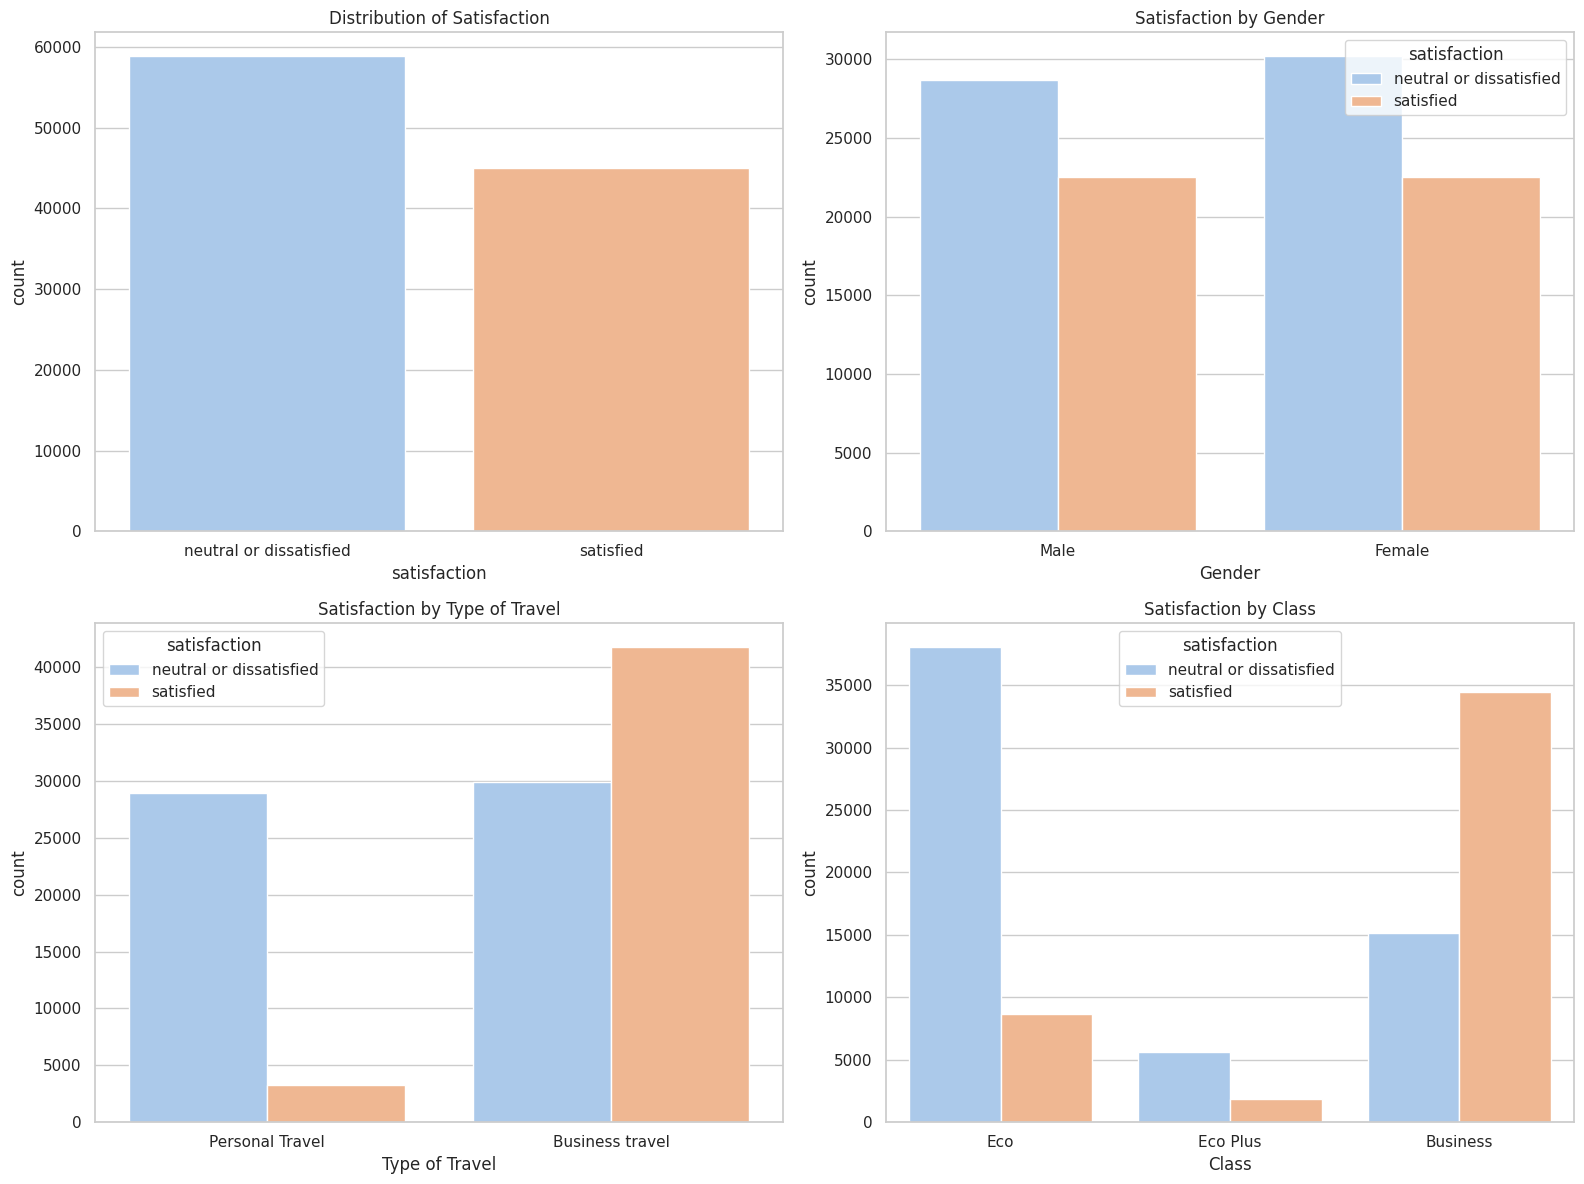

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ターゲット変数 (satisfaction) の分布
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(x='satisfaction', data=train, ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Distribution of Satisfaction')

# 性別 (Gender) と満足度の関係
sns.countplot(x='Gender', hue='satisfaction', data=train, ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Satisfaction by Gender')

# 旅行目的 (Type of Travel) と満足度の関係
sns.countplot(x='Type of Travel', hue='satisfaction', data=train, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Satisfaction by Type of Travel')

# 顧客クラス (Class) と満足度の関係
sns.countplot(x='Class', hue='satisfaction', data=train, ax=axes[1, 1], palette='pastel', order=['Eco', 'Eco Plus', 'Business'])
axes[1, 1].set_title('Satisfaction by Class')

plt.tight_layout()
plt.show()

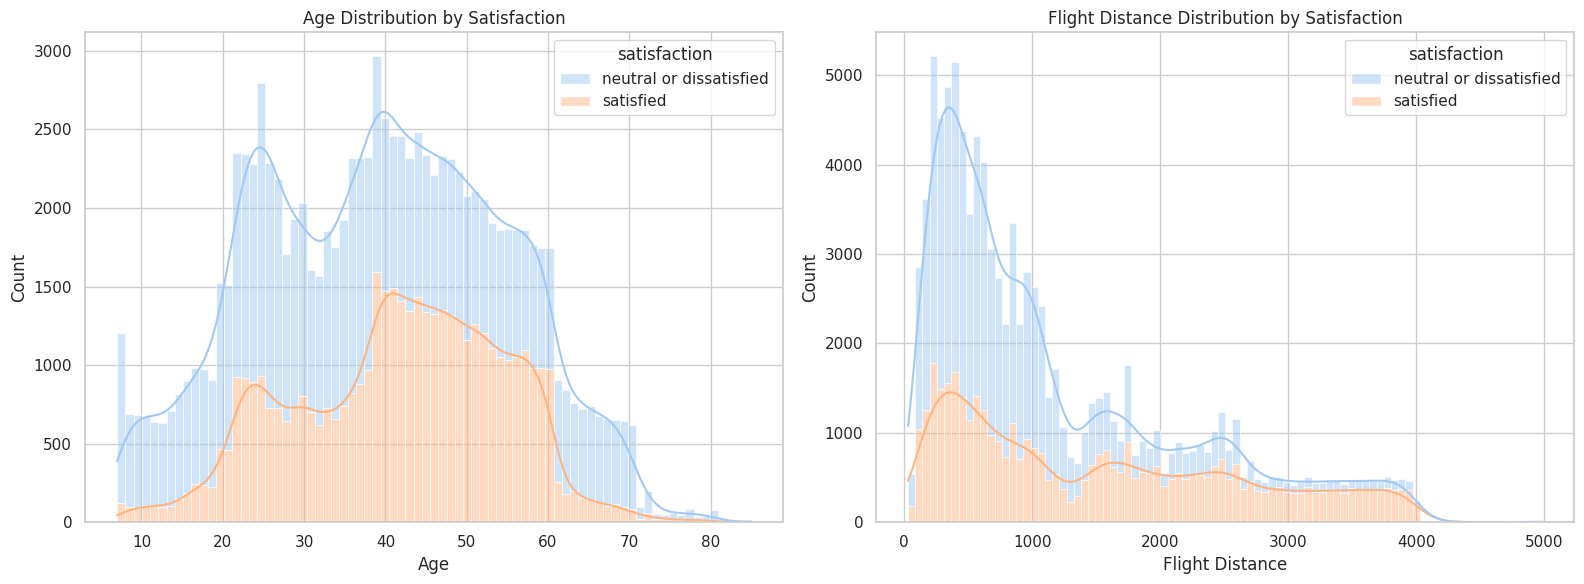

In [7]:
# 年齢 (Age) とフライト距離 (Flight Distance) の分布を満足度別に可視化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=train, x='Age', hue='satisfaction', kde=True, ax=axes[0], palette='pastel', multiple='stack')
axes[0].set_title('Age Distribution by Satisfaction')

sns.histplot(data=train, x='Flight Distance', hue='satisfaction', kde=True, ax=axes[1], palette='pastel', multiple='stack')
axes[1].set_title('Flight Distance Distribution by Satisfaction')

plt.tight_layout()
plt.show()

### 3. データの前処理 (Preprocessing)

In [8]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def preprocess_data(df, is_train=True):
    # コピーを作成
    data = df.copy()

    # 不要な列の削除
    cols_to_drop = ['Unnamed: 0', 'id']
    data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

    # 欠損値補完（Arrival Delay in Minutes の欠損値を中央値で補完）
    if 'Arrival Delay in Minutes' in data.columns:
        data['Arrival Delay in Minutes'] = data['Arrival Delay in Minutes'].fillna(data['Arrival Delay in Minutes'].median())

    # カテゴリ変数のラベルエンコーディング
    categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
    for col in categorical_cols:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

    # ターゲット変数の変換 (trainデータのみ)
    if is_train and 'satisfaction' in data.columns:
        data['satisfaction'] = data['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

    return data

# 前処理の適用
train_clean = preprocess_data(train, is_train=True)
test_clean = preprocess_data(test, is_train=False)

# 結果の確認
print("Train clean shape:", train_clean.shape)
print("Test clean shape:", test_clean.shape)
display(train_clean.head())

Train clean shape: (103904, 23)
Test clean shape: (25976, 23)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


### 4. ベースラインモデルの構築と評価 (LightGBM)

In [9]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# 特徴量とターゲットの分離
X = train_clean.drop(columns=['satisfaction'])
y = train_clean['satisfaction']

# 学習データと検証データに分割
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# LightGBMモデルの構築・学習
model = lgb.LGBMClassifier(random_state=42, verbose=-1)
model.fit(X_train, y_train)

# 検証データでの予測と評価
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.9649

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11776
           1       0.97      0.94      0.96      9005

    accuracy                           0.96     20781
   macro avg       0.97      0.96      0.96     20781
weighted avg       0.97      0.96      0.96     20781



### 5. テストデータでの予測と結果の保存

In [10]:
# テストデータの予測に必要な列のみを取得 (satisfaction列が含まれている場合は除外)
X_test = test_clean.drop(columns=['satisfaction'], errors='ignore')

# テストデータでの予測実行
test_predictions = model.predict(X_test)

# 予測値を元のラベル文字列に戻すマッピング (0 -> 'neutral or dissatisfied', 1 -> 'satisfied')
satisfaction_map = {0: 'neutral or dissatisfied', 1: 'satisfied'}
predicted_labels = [satisfaction_map[pred] for pred in test_predictions]

# 提出用・保存用データフレームの構築 (元の test データから id を流用)
submission = pd.DataFrame({
    'id': test['id'],
    'satisfaction': predicted_labels
})

# CSVファイルとして保存
output_path = f'{OUT_DIR}/submission.csv'
submission.to_csv(output_path, index=False)

print(f"予測結果を保存しました: {output_path}")
print(submission.head())

予測結果を保存しました: /content/outputs/airline/submission.csv
      id             satisfaction
0  19556                satisfied
1  90035                satisfied
2  12360  neutral or dissatisfied
3  77959                satisfied
4  36875  neutral or dissatisfied


### 6. 特徴量の重要度（Feature Importance）の可視化

/tmp/ipykernel_676/1077671549.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


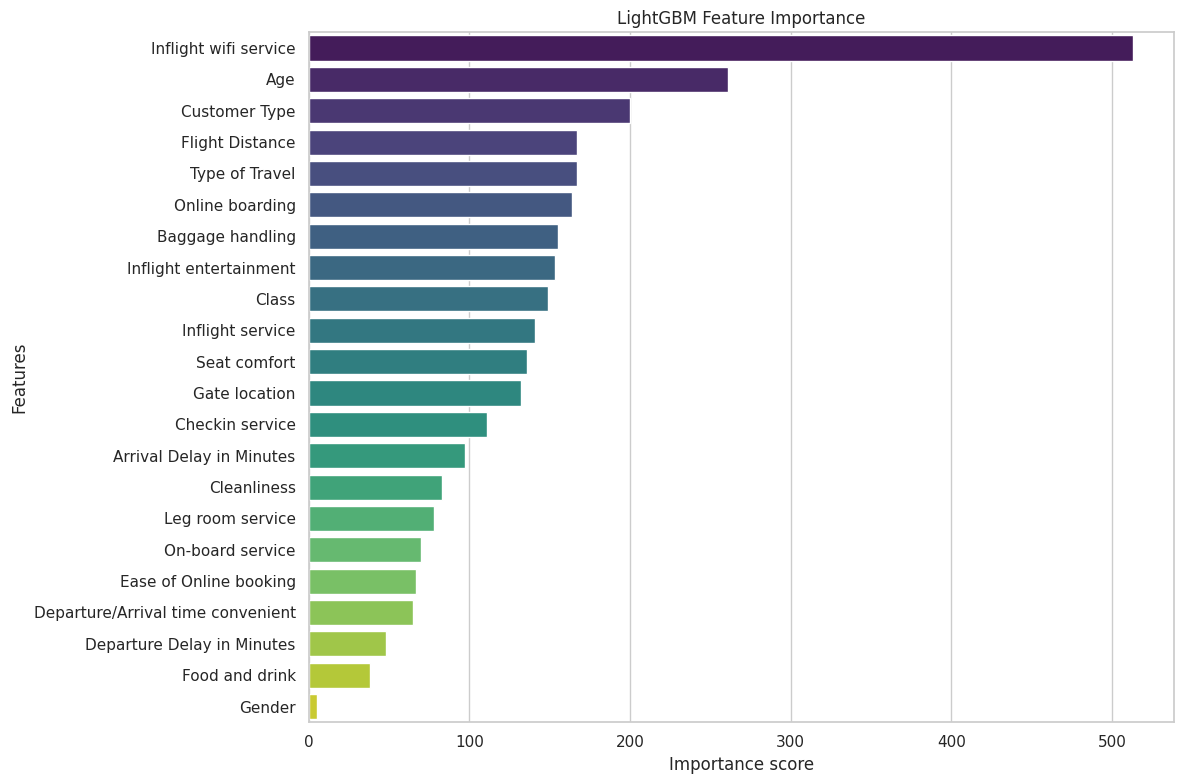

In [11]:
# 特徴量重要度の取得
importances = model.feature_importances_
feature_names = X.columns

# データフレームにまとめてソート
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# プロット
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### 7. Optuna によるハイパーパラメータチューニング (Hyperparameter Tuning with Optuna)

In [12]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.6 MB/s eta 0:00:00


In [13]:
import optuna
import lightgbm as lgb
from sklearn.metrics import accuracy_score
import logging

# Optuna のログ出力を警告のみにする
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 探索するパラメータ空間の定義
    params = {
        'objective': 'binary',
        'metric': 'binary_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }

    # モデルの訓練
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    # 予測と評価
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)

    return accuracy

# セッションの作成と実行 (時間の都合上、トライアル数を15回に設定)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print("ベストな Validation Accuracy: ", study.best_value)
print("ベストなハイパーパラメータ: ")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

ベストな Validation Accuracy:  0.9629950435493961
ベストなハイパーパラメータ: 
  learning_rate: 0.051854788753468384
  num_leaves: 69
  max_depth: 11
  min_child_samples: 49
  subsample: 0.8161313763981226
  colsample_bytree: 0.7231723939331385


### 8. 最適パラメータによる最終モデルの学習と予測ファイルの作成

In [14]:
# 最適パラメータの適用 (Optuna の実行結果をもとに設定)
best_params = study.best_params
best_params['objective'] = 'binary'
best_params['metric'] = 'binary_error'
best_params['verbosity'] = -1
best_params['boosting_type'] = 'gbdt'
best_params['random_state'] = 42

# 特徴量とターゲットの再定義
X_all = train_clean.drop(columns=['satisfaction'])
y_all = train_clean['satisfaction']

# 全訓練データを使用した再学習
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_all, y_all)

# テストデータの予測作成
X_test = test_clean.drop(columns=['satisfaction'], errors='ignore')
final_predictions = final_model.predict(X_test)

# 予測ラベルへの変換
final_labels = [satisfaction_map[pred] for pred in final_predictions]

# 提出ファイルの更新
final_submission = pd.DataFrame({
    'id': test['id'],
    'satisfaction': final_labels
})

output_path = f'{OUT_DIR}/submission.csv'
final_submission.to_csv(output_path, index=False)

print(f"最適化済みモデルによる予測結果を再保存しました: {output_path}")
print(final_submission.head())

最適化済みモデルによる予測結果を再保存しました: /content/outputs/airline/submission.csv
      id             satisfaction
0  19556                satisfied
1  90035                satisfied
2  12360  neutral or dissatisfied
3  77959                satisfied
4  36875  neutral or dissatisfied
